# Notebook 11 — Hybrid Pipeline Demo

**Pipeline:** Contract text → Legal-BERT clause detection → RF risk classification

This notebook demonstrates an end-to-end prediction on a single contract. All results
are live — no hardcoded outputs.

In [1]:
# ── Cell 1: Path bootstrap ──────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists()), None
)
assert PROJECT_ROOT, 'Could not locate project root containing src/'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: /Users/subhammahapatra/Downloads/agastya


In [ ]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RF_MODEL_PATH   = PROJECT_ROOT / 'results/phase3/rf_reasoner.pkl'
LABEL_MAP_PATH  = PROJECT_ROOT / 'results/phase2/label2id.json'
print('Imports OK')

Imports OK


## 1. Load RF Reasoner

In [3]:
# ── Cell 3: Load RF reasoner ─────────────────────────────────────────────────
from src.phase3.rf_reasoner import load_rf_reasoner, get_feature_importances

reasoner = load_rf_reasoner(str(RF_MODEL_PATH))
feature_labels = reasoner['feature_labels']

print(f'RF model loaded. Feature space: {len(feature_labels)} labels')
print(f'Classes: {list(reasoner["model"].classes_)}')

RF model loaded. Feature space: 41 labels
Classes: ['High', 'Low', 'Medium']


## 2. Live Demo — Single Contract Prediction

We use `predict_from_clauses()` to bypass BERT (requires GPU) and demonstrate
the RF reasoning layer directly with ground-truth clause labels from the test set.

In [4]:
# ── Cell 4: Load a real contract from the test set ───────────────────────────
test_csv = PROJECT_ROOT / 'data/processed/test.csv'
df = pd.read_csv(test_csv)

# Pick first contract for demo
demo_filename = df['filename'].iloc[0]
demo_labels = list(df[df['filename'] == demo_filename]['label'].dropna().unique())

print(f'Contract: {demo_filename}')
print(f'Detected clause types ({len(demo_labels)}):')
for lbl in sorted(demo_labels):
    print(f'  - {lbl}')

Contract: IdeanomicsInc_20160330_10-K_EX-10.26_9512211_EX-10.26_Content License Agreement.pdf
Detected clause types (14):
  - Agreement Date
  - Anti-Assignment
  - Audit Rights
  - Cap On Liability
  - Document Name
  - Effective Date
  - Expiration Date
  - Governing Law
  - Irrevocable Or Perpetual License
  - License Grant
  - Parties
  - Revenue/Profit Sharing
  - Rofr/Rofo/Rofn
  - Uncapped Liability


In [5]:
# ── Cell 5: RF risk prediction ───────────────────────────────────────────────
from src.phase3.rf_reasoner import predict_risk

result = predict_risk(reasoner, set(demo_labels))

risk  = result['risk_level']
probs = result['probabilities']

print(f'\n── RF Prediction ──────────────────────────────')
print(f'Risk Level:  {risk}')
print(f'High:        {probs["High"]:.4f}')
print(f'Medium:      {probs["Medium"]:.4f}')
print(f'Low:         {probs["Low"]:.4f}')


── RF Prediction ──────────────────────────────
Risk Level:  High
High:        1.0000
Medium:      0.0000
Low:         0.0000


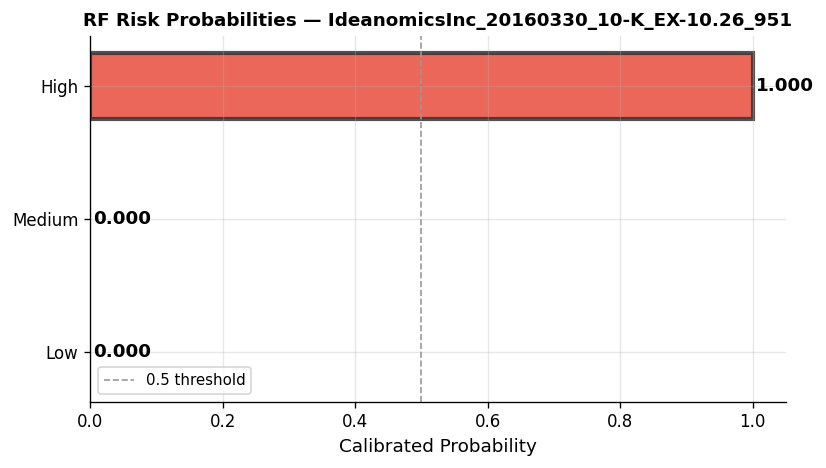

In [6]:
# ── Cell 6: Probability breakdown chart ──────────────────────────────────────
labels_plot = ['High', 'Medium', 'Low']
prob_vals   = [probs['High'], probs['Medium'], probs['Low']]
colors_plot = ['#e74c3c', '#e67e22', '#27ae60']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels_plot[::-1], prob_vals[::-1],
               color=colors_plot[::-1], alpha=0.85, height=0.5,
               edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, prob_vals[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.axvline(0.5, color='#999', linestyle='--', linewidth=1, label='0.5 threshold')
ax.set_xlabel('Calibrated Probability', fontsize=11)
ax.set_xlim(0, 1.05)
ax.set_title(f'RF Risk Probabilities — {demo_filename[:40]}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Highlight predicted class
predicted_idx = labels_plot[::-1].index(risk)
bars[predicted_idx].set_edgecolor('#333')
bars[predicted_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/demo_probability_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Vector Inspection

In [7]:
# ── Cell 7: Feature vector — active features ──────────────────────────────────
fv = np.array(result['feature_vector'])
active = [(feature_labels[i], fv[i]) for i in np.where(fv > 0)[0]]
active.sort(key=lambda x: -x[1])

print(f'Active features ({len(active)}/{len(feature_labels)} non-zero):')
print(f'{"Clause Label":<40} {"Count"}')
print('-' * 50)
for label, count in active:
    print(f'{label:<40} {int(count)}')

Active features (14/41 non-zero):
Clause Label                             Count
--------------------------------------------------
Agreement Date                           1
Anti-Assignment                          1
Audit Rights                             1
Cap On Liability                         1
Document Name                            1
Effective Date                           1
Expiration Date                          1
Governing Law                            1
Irrevocable Or Perpetual License         1
License Grant                            1
Parties                                  1
Revenue/Profit Sharing                   1
Rofr/Rofo/Rofn                           1
Uncapped Liability                       1


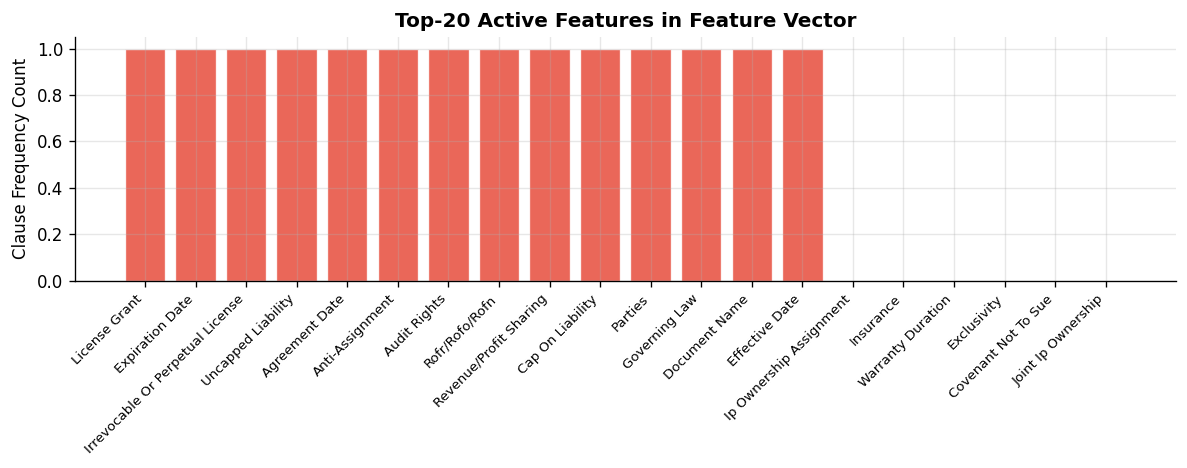

In [8]:
# ── Cell 8: Feature vector heatmap ───────────────────────────────────────────
fv_reshaped = fv.reshape(1, -1)
top_n = 20
top_idx = np.argsort(fv)[::-1][:top_n]
top_labels = [feature_labels[i] for i in top_idx]
top_vals   = fv[top_idx]

fig, ax = plt.subplots(figsize=(10, 4))
colors_ = ['#e74c3c' if v > 0 else '#ecf0f1' for v in top_vals]
bars = ax.bar(range(top_n), top_vals, color=colors_, alpha=0.85,
              edgecolor='white', linewidth=0.8)
ax.set_xticks(range(top_n))
ax.set_xticklabels(top_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Clause Frequency Count', fontsize=10)
ax.set_title(f'Top-{top_n} Active Features in Feature Vector', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/demo_feature_vector.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Pipeline Architecture Summary

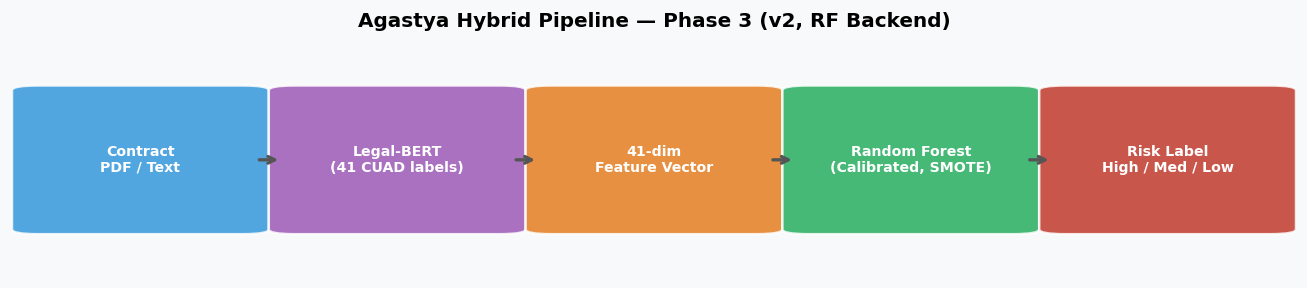

In [9]:
# ── Cell 9: Architecture flow diagram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

steps = [
    ('Contract\nPDF / Text', '#3498db'),
    ('Legal-BERT\n(41 CUAD labels)', '#9b59b6'),
    ('41-dim\nFeature Vector', '#e67e22'),
    ('Random Forest\n(Calibrated, SMOTE)', '#27ae60'),
    ('Risk Label\nHigh / Med / Low', '#c0392b'),
]

n = len(steps)
w = 1.0 / n
for i, (label, color) in enumerate(steps):
    x = i * w + w / 2
    rect = mpatches.FancyBboxPatch((x - 0.08, 0.2), 0.16, 0.6,
                                   boxstyle='round,pad=0.02',
                                   facecolor=color, alpha=0.85,
                                   edgecolor='white', linewidth=1.5,
                                   transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x, 0.5, label, ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold', transform=ax.transAxes)
    if i < n - 1:
        ax.annotate('', xy=((i + 1) * w + 0.01, 0.5),
                    xytext=(i * w + w - 0.01, 0.5),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))

ax.set_title('Agastya Hybrid Pipeline — Phase 3 (v2, RF Backend)', fontsize=12,
             fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/pipeline_architecture.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Step | Component | Output |
|------|-----------|--------|
| 1 | Contract text extraction | Raw text |
| 2 | Legal-BERT (LoRA fine-tuned) | 41-class clause labels + confidence scores |
| 3 | Feature engineering | 41-dim clause frequency vector |
| 4 | Random Forest (calibrated, SMOTE) | P(High), P(Medium), P(Low) |
| 5 | Argmax | Final risk label |